In [1]:
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from datasets import load_dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

print("Loading datasets...")
conv_dataset = load_dataset("JiaqiXue/mmr-routing-20k", data_files="data/conversations.jsonl", split="train")
features_dataset = load_dataset("JiaqiXue/mmr-routing-20k", data_files="data/features/qwen06b_20k.jsonl", split="train")

df_conv = conv_dataset.to_pandas()
df_features = features_dataset.to_pandas()

# Merge and extract features
df_merged = pd.merge(df_conv, df_features, on="conversation_hash")
expanded_features = pd.json_normalize(df_merged['features'])
df_merged = pd.concat([df_merged.drop(columns=['features']), expanded_features], axis=1)

# Sanitization:Clip all scores to a strict 0 to 10 range to prevent anomalies
df_merged['strong_score'] = np.clip(df_merged['strong_score'], 0.0, 10.0)
df_merged['weak_score'] = np.clip(df_merged['weak_score'], 0.0, 10.0)
df_merged = df_merged.sort_values(by=['conversation_hash', 'turn_idx']).reset_index(drop=True)

#Split the conversations in 2 sets(while keeping all questions of a conversation in the same set)
unique_conversations = list(df_merged['conversation_hash'].unique())
train_hashes, test_hashes = train_test_split(unique_conversations, test_size=0.2, random_state=42)

df_train = df_merged[df_merged['conversation_hash'].isin(train_hashes)].reset_index(drop=True)
df_test = df_merged[df_merged['conversation_hash'].isin(test_hashes)].reset_index(drop=True)

print(f"Data Prep Complete! Train rows: {len(df_train)} | Test rows: {len(df_test)}")

Loading datasets...


Data Prep Complete! Train rows: 64678 | Test rows: 16197


In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class AdvancedRoutingEnv(gym.Env):
    def __init__(self, df, feature_means=None, feature_stds=None):
        super().__init__()
        self.df = df
        self.total_steps = len(df)

        # Set budget and tax rate
        self.initial_budget = 10000.0
        self.tax_rate = 0.025
        # 8 Linguistic Features + 1 Budget Feature = 9 Dimensions
        self.feature_cols = [
            'difficulty', 'query_len_words', 'is_short_query',
            'has_pronoun_reference', 'is_first_turn', 'turn_position_ratio',
            'has_continuation_marker', 'word_overlap_prev_query'
        ]

        self.features_array = self.df[self.feature_cols].fillna(0).astype(np.float32).values
        self.strong_scores = self.df['strong_score'].values
        self.weak_scores = self.df['weak_score'].values
        self.query_lens = self.df['query_len_words'].values

        # Normalization: Z-score normalise all features(also make sure testing and training use same mean and std) by obtaining mean and std
        if feature_means is not None and feature_stds is not None:
            self.feature_means = feature_means
            self.feature_stds = feature_stds
        else:
            self.feature_means = np.mean(self.features_array, axis=0)
            self.feature_stds = np.std(self.features_array, axis=0) + 1e-8
        #Define action space and observation space
        self.action_space = spaces.Discrete(2)

        # Observation space boundaries for normalized data + budget ratio variable
        self.observation_space = spaces.Box(
            low=-10.0, high=10.0, shape=(len(self.feature_cols) + 1,), dtype=np.float32
        )
        #Reset after every run
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.remaining_budget = self.initial_budget
        return self._get_state(), {}

    def _get_state(self):
        if self.current_step >= self.total_steps:
            return np.zeros(len(self.feature_cols) + 1, dtype=np.float32)
         #Obtain and normalize features
        raw_features = self.features_array[self.current_step]
        normalized_features = (raw_features - self.feature_means) / self.feature_stds
        #Create budget ratio and add it to normalized features
        budget_ratio = max(0.0, self.remaining_budget / self.initial_budget)

        return np.append(normalized_features, budget_ratio).astype(np.float32)

    def step(self, action):
        # Safely pull raw un-normalized length for deterministic pricing calculations
        q_len = self.query_lens[self.current_step]

        strong_cost = q_len + 80 + int(q_len * 2.0)
        weak_cost = q_len + 15 + int(q_len * 0.8)

        # 1. THE ABSOLUTE BANKRUPTCY CHECK
        if self.remaining_budget < weak_cost:
            return self._get_state(), -10.0, True, False, {"status": "bankrupt", "budget": self.remaining_budget}

        # 2. RESOLVE THE ACTION & APPLY FALLBACKS
        if action == 1 and self.remaining_budget < strong_cost:
            # Agent can't afford Strong. Force fallback to Weak, apply pacing tax penalty.
            actual_cost = weak_cost
            base_reward = self.weak_scores[self.current_step] - (weak_cost * self.tax_rate)
            reward = base_reward - 2.0
            status = "fallback_to_weak"

        elif action == 1:
            # Normal Strong execution
            actual_cost = strong_cost
            reward = self.strong_scores[self.current_step] - (strong_cost * self.tax_rate)
            status = "success_strong"

        else:
            # Normal Weak execution
            actual_cost = weak_cost
            reward = self.weak_scores[self.current_step] - (weak_cost * self.tax_rate)
            status = "success_weak"

        # 3. ADVANCE THE STATE
        self.remaining_budget -= actual_cost
        self.current_step += 1
        terminated = self.current_step >= self.total_steps

        return self._get_state(), reward, terminated, False, {"status": status, "budget": self.remaining_budget}

In [3]:
from sklearn.ensemble import RandomForestClassifier
from stable_baselines3 import PPO
import pandas as pd

print("Training Random Forest Baseline...")
def get_rf_target(row):
    q_len = row['query_len_words']
    strong_cost = q_len + 80 + int(q_len * 2.0)
    weak_cost = q_len + 15 + int(q_len * 0.8)
    strong_net = row['strong_score'] - (strong_cost * 0.025)
    weak_net = row['weak_score'] - (weak_cost * 0.025)
    return 1 if strong_net > weak_net else 0

y_train = df_train.apply(get_rf_target, axis=1)
X_train = df_train[AdvancedRoutingEnv(df_train).feature_cols].fillna(0)

rf_classifier = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf_classifier.fit(X_train, y_train)

#Setting up RL Agent and Environment
train_env = AdvancedRoutingEnv(df_train)

# Use the mean and std
train_means = train_env.feature_means
train_stds = train_env.feature_stds

rl_model = PPO(
    "MlpPolicy",
    train_env,
    policy_kwargs=dict(net_arch=[128, 128]),
    ent_coef=0.01,
    learning_rate=0.0005,
    verbose=0,
    seed=42
)

print("Training RL Agent")
rl_model.learn(total_timesteps=250000)

print("Training Complete! Agent is locked in and ready for final evaluation.")

Training Random Forest Baseline...
Training RL Agent
Training Complete! Agent is locked in and ready for final evaluation.


In [4]:
#Final Evaluation
def evaluate_strategy(strategy_name, df_eval):
  # Use the same mean and std
    eval_env = AdvancedRoutingEnv(df_eval, feature_means=train_means, feature_stds=train_stds)
    obs, _ = eval_env.reset()

    total_quality = 0
    queries_answered = 0
    done = False
    latest_info = {"budget": eval_env.initial_budget}

    if strategy_name == "Random Forest":
        X_test = df_eval[eval_env.feature_cols].fillna(0)
        rf_predictions = rf_classifier.predict(X_test)

    while not done:
        idx = eval_env.current_step
        if idx >= eval_env.total_steps:
            break

        if strategy_name == "RL Agent":
            action, _ = rl_model.predict(obs, deterministic=True)
            action = int(action)
        elif strategy_name == "Always Weak":
            action = 0
        elif strategy_name == "Always Strong":
            action = 1
        elif strategy_name == "Random Forest":
            action = int(rf_predictions[idx])
        elif strategy_name == "Threshold Heuristic":
            current_difficulty = df_eval['difficulty'].iloc[idx]
            action = 1 if current_difficulty > 5.0 else 0

        obs, reward, terminated, truncated, info = eval_env.step(action)
        latest_info = info


        if info.get("status") != "bankrupt":
            total_quality += reward
            queries_answered += 1

        done = terminated or truncated

    return queries_answered, total_quality, latest_info.get('budget', 0.0)

print("Running Final Evaluation on Unseen Test Data...\n")
strategies = ["Always Weak", "Always Strong", "Threshold Heuristic", "Random Forest", "RL Agent"]
results = []

for strat in strategies:
    queries, quality, final_budget = evaluate_strategy(strat, df_test)
    results.append({
        "Strategy": strat,
        "Queries Answered": queries,
        "Quality Score": round(quality, 2),
        "Remaining Tokens": round(final_budget, 2)
    })

print(pd.DataFrame(results).to_string(index=False))

Running Final Evaluation on Unseen Test Data...

           Strategy  Queries Answered  Quality Score  Remaining Tokens
        Always Weak               116         362.53            1061.0
      Always Strong                49         215.08               3.0
Threshold Heuristic                82         417.20               8.0
      Random Forest                73         412.82              33.0
           RL Agent                85         435.22              49.0


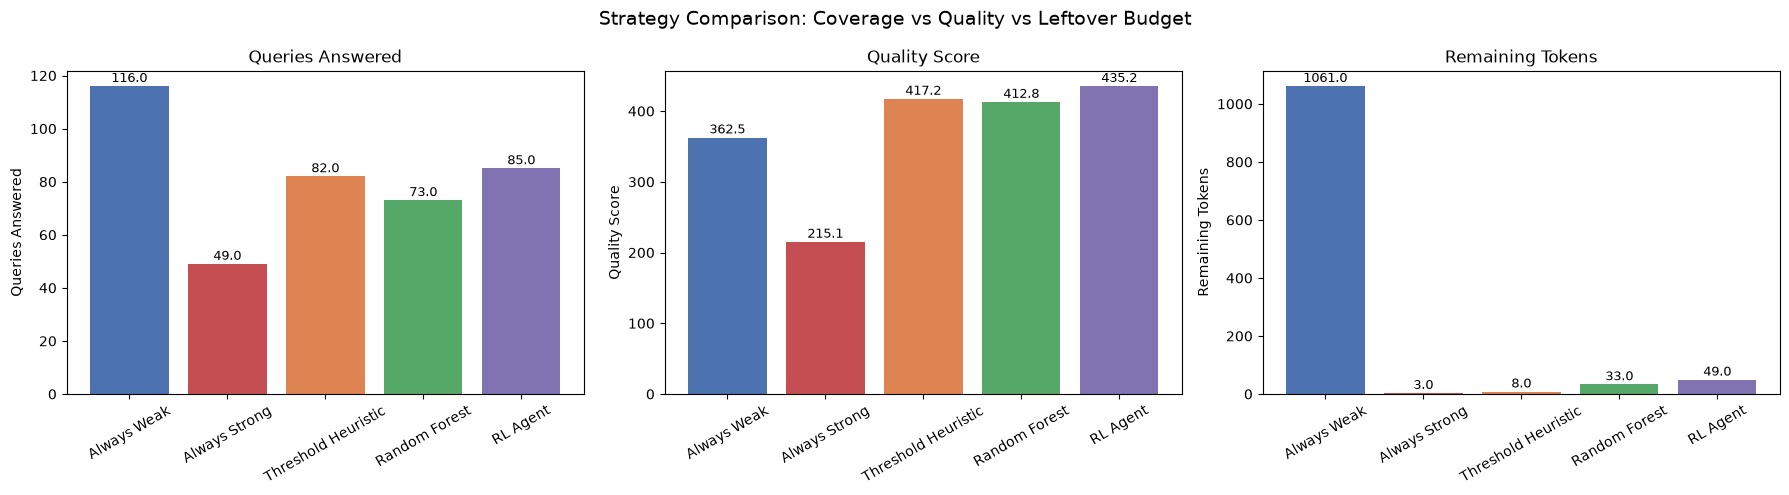

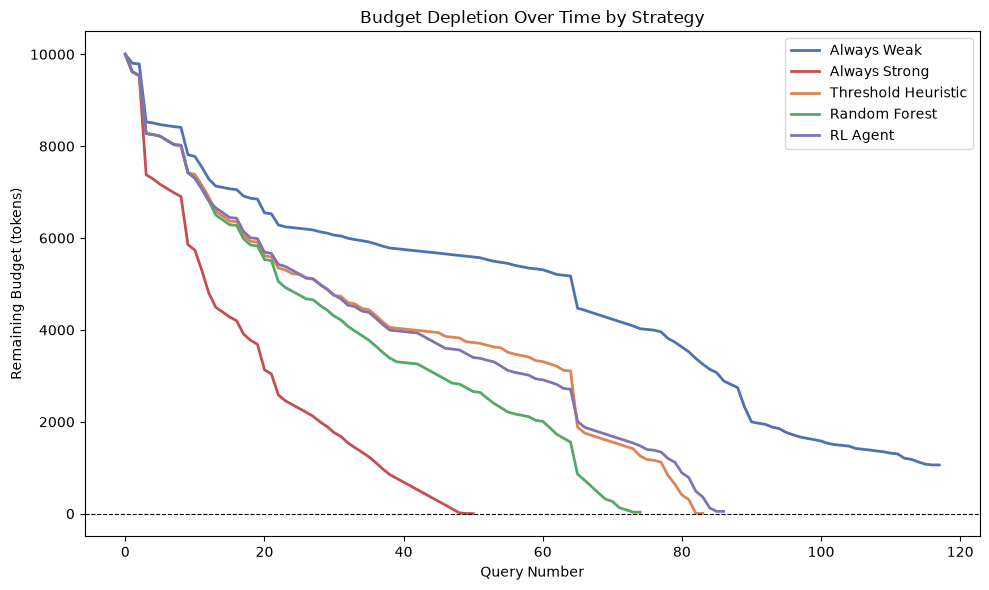

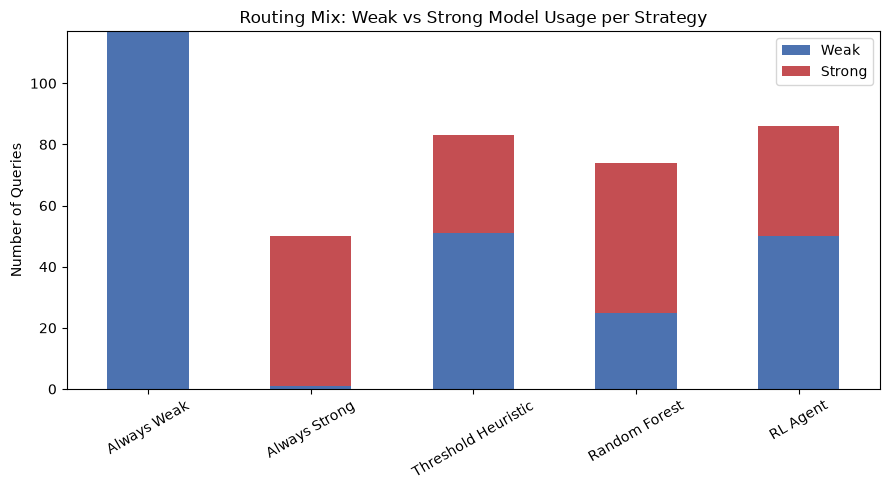

In [ ]:
#Visualization
import matplotlib.pyplot as plt
import pandas as pd

results_df = pd.DataFrame(results)
strategy_colors = {
    "Always Weak": "#4C72B0",
    "Always Strong": "#C44E52",
    "Threshold Heuristic": "#DD8452",
    "Random Forest": "#55A868",
    "RL Agent": "#8172B2",
}
colors = [strategy_colors[s] for s in results_df["Strategy"]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


metrics = ["Queries Answered", "Quality Score", "Remaining Tokens"]

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df["Strategy"], results_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.suptitle("Strategy Comparison: Coverage vs Quality vs Leftover Budget", fontsize=14)
plt.tight_layout()
plt.savefig("strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


def evaluate_strategy_with_trace(strategy_name, df_eval):
    eval_env = AdvancedRoutingEnv(df_eval, feature_means=train_means, feature_stds=train_stds)
    obs, _ = eval_env.reset()

    budget_trace = [eval_env.initial_budget]
    action_trace = []
    done = False

    if strategy_name == "Random Forest":
        X_test = df_eval[eval_env.feature_cols].fillna(0)
        rf_predictions = rf_classifier.predict(X_test)

    while not done:
        idx = eval_env.current_step
        if idx >= eval_env.total_steps:
            break

        if strategy_name == "RL Agent":
            action, _ = rl_model.predict(obs, deterministic=True)
            action = int(action)
        elif strategy_name == "Always Weak":
            action = 0
        elif strategy_name == "Always Strong":
            action = 1
        elif strategy_name == "Random Forest":
            action = int(rf_predictions[idx])
        elif strategy_name == "Threshold Heuristic":
            current_difficulty = df_eval['difficulty'].iloc[idx]
            action = 1 if current_difficulty > 5.0 else 0

        obs, reward, terminated, truncated, info = eval_env.step(action)
        budget_trace.append(info.get("budget", budget_trace[-1]))
        
        # TRACE FIX: Log what actually happened based on your Cell 2's info dictionary
        if info.get("status") == "fallback_to_weak":
            actual_executed_action = 0  
        else:
            actual_executed_action = action
            
        action_trace.append(actual_executed_action)
        done = terminated or truncated

    return budget_trace, action_trace

traces = {strat: evaluate_strategy_with_trace(strat, df_test) for strat in strategies}


plt.figure(figsize=(10, 6))
for strat in strategies:
    budget_trace, _ = traces[strat]
    plt.plot(budget_trace, label=strat, color=strategy_colors[strat], linewidth=2)

plt.xlabel("Query Number")
plt.ylabel("Remaining Budget (tokens)")
plt.title("Budget Depletion Over Time by Strategy")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.legend()
plt.tight_layout()
plt.savefig("budget_depletion.png", dpi=150, bbox_inches="tight")
plt.show()


action_counts = {
    strat: {"Weak": action_trace.count(0), "Strong": action_trace.count(1)}
    for strat, (_, action_trace) in traces.items()
}
action_df = pd.DataFrame(action_counts).T

action_df.plot(kind="bar", stacked=True, figsize=(9, 5), color=["#4C72B0", "#C44E52"])
plt.title("Routing Mix: Weak vs Strong Model Usage per Strategy")
plt.ylabel("Number of Queries")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("routing_mix.png", dpi=150, bbox_inches="tight")
plt.show()